In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

dataset_folder = r"C:\Users\michael\Desktop\IDX Exchange\Files\datasets"
os.chdir(dataset_folder)

In [2]:
df_sold = pd.read_csv("CRMLSSold_5.csv", low_memory = False)
df_listings = pd.read_csv("CRMLSListing_5.csv", low_memory = False)

In [3]:
df_sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,rate_30yr_fixed,geometry,DistrictName,price_ratio,PPSF,days_on_market,YrMo,close_to_original_list_ratio,listing_to_contract_days,contract_to_close_days
0,ContraCosta,ContraCosta,"Tile,Wood",NaN,False,5000000.0,1095075487,2024-01-18,5000000.0,Erin,...,6.6425,POINT (-122.08132056 37.88530534),NaN,1.0,1148.369316,0,2024-01,1.0,0.0,63.0
1,NaN,Mlslistings,NaN,False,NaN,NaN,1079166779,2024-01-30,858000.0,David,...,6.6425,POINT (-116.54053587 33.84982832),Palm Springs Unified,NaN,430.075188,0,2024-01,NaN,0.0,0.0
2,Glendale,Southland,NaN,False,False,1890500.0,1075037759,2024-01-29,1890500.0,Karen,...,6.6425,POINT (-118.558749 34.164376),Los Angeles Unified,1.0,591.891046,0,2024-01,1.0,0.0,0.0
3,NorthSanLuisObispo,NorthSanLuisObispo,NaN,True,False,2100000.0,1067652762,2024-01-02,2100000.0,Jennifer,...,6.6425,POINT (-120.646786 35.277199),San Luis Coastal Unified,1.0,562.098501,0,2024-01,1.0,0.0,48.0
4,Mlslistings,Mlslistings,"Tile,Wood",True,NaN,NaN,1061988701,2024-01-31,2340000.0,Danny,...,6.6425,POINT (-121.78025459 37.32544564),NaN,NaN,958.230958,0,2024-01,NaN,0.0,0.0


In [4]:
df_listings.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,rate_30yr_fixed,geometry,DistrictName,price_ratio,PPSF,days_on_market,YrMo,close_to_original_list_ratio,listing_to_contract_days,contract_to_close_days
0,759000.0,1159972295,NaN,NaN,Richard,Sirois,33.738910,-116.198447,42680 Incantata Place,Residential,...,6.6425,POINT (-116.198447 33.73891),Desert Sands Unified,NaN,NaN,36,NaN,NaN,NaN,NaN
1,320000.0,1159871345,2026-05-11,320000.0,Nicholas,Miller,33.842793,-116.481803,28388 Desert Princess Drive,Residential,...,6.6425,POINT (-116.481803 33.842793),Palm Springs Unified,1.0000,264.026403,0,2026-05,1.0000,851.0,0.0
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,6.6425,POINT (-122.861472 39.125903),Upper Lake Unified,1.3805,158.730159,10,2026-04,1.3805,804.0,25.0
3,2500000.0,1146529264,2026-04-17,2000000.0,Clifford,Stevens,34.150964,-118.390267,4415 Morella Ave,Residential,...,6.6425,POINT (-118.390267 34.150964),Los Angeles Unified,0.8000,777.302759,98,2026-04,0.8000,785.0,29.0
4,3200000.0,1118382573,2025-05-21,3200000.0,Trudy,McGrath,33.028788,-117.264434,1200 Cardiff Drive,Residential,...,6.6425,POINT (-117.264434 33.028788),NaN,1.0000,2317.161477,0,2025-05,1.0000,58.0,421.0


In [5]:
def quartiles(df, field):
    Q1 = df[field].quantile(0.25)
    Q3 = df[field].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return float(lower), float(upper)


def flag_outliers(df, field):
    field_lower, field_upper = quartiles(df, field)
    df[f"{field}_outlier_flag"] = 0
    df.loc[(df[field] < field_lower) | (df[field] > field_upper), f"{field}_outlier_flag"] = 1
    return df

In [6]:
key_numeric_fields = ["ClosePrice", "LivingArea", "DaysOnMarket"]
outlier_flags = ["ClosePrice_outlier_flag", "LivingArea_outlier_flag", "DaysOnMarket_outlier_flag"]

In [7]:
for field in key_numeric_fields:
    flag_outliers(df_sold, field)
    flag_outliers(df_listings, field)

In [8]:
df_sold[key_numeric_fields + outlier_flags].head()

,ClosePrice,LivingArea,DaysOnMarket,ClosePrice_outlier_flag,LivingArea_outlier_flag,DaysOnMarket_outlier_flag
0,5000000.0,4354.0,0,1,1,0
1,858000.0,1995.0,0,0,0,0
2,1890500.0,3194.0,0,0,0,0
3,2100000.0,3736.0,0,0,1,0
4,2340000.0,2442.0,0,1,0,0


In [9]:
df_sold[outlier_flags].sum()

ClosePrice_outlier_flag      30559
LivingArea_outlier_flag      17631
DaysOnMarket_outlier_flag    29100
dtype: int64

In [21]:
df_listings[key_numeric_fields + outlier_flags].head()

,ClosePrice,LivingArea,DaysOnMarket,ClosePrice_outlier_flag,LivingArea_outlier_flag,DaysOnMarket_outlier_flag
0,NaN,2338.0,36,0,0,0
1,320000.0,1212.0,0,0,0,0
2,160000.0,1008.0,10,0,0,0
3,2000000.0,2573.0,98,0,0,0
4,3200000.0,1381.0,0,1,0,0


In [22]:
df_listings[outlier_flags].sum()

ClosePrice_outlier_flag      27591
LivingArea_outlier_flag      20879
DaysOnMarket_outlier_flag    34697
dtype: int64

In [12]:
def create_filtered_df(df):
    df_filtered = df.copy()
    df_filtered = df_filtered[(df_filtered.ClosePrice_outlier_flag == 0) & (df_filtered.LivingArea_outlier_flag == 0) & (df_filtered.DaysOnMarket_outlier_flag == 0)]
    df_filtered = df_filtered.drop(columns = ["ClosePrice_outlier_flag", "LivingArea_outlier_flag", "DaysOnMarket_outlier_flag"])
    return df_filtered

In [13]:
df_sold_filtered = create_filtered_df(df_sold)
df_listings_filtered = create_filtered_df(df_listings)

In [14]:
df_sold_filtered.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,rate_30yr_fixed,geometry,DistrictName,price_ratio,PPSF,days_on_market,YrMo,close_to_original_list_ratio,listing_to_contract_days,contract_to_close_days
1,NaN,Mlslistings,NaN,False,NaN,NaN,1079166779,2024-01-30,858000.0,David,...,6.6425,POINT (-116.54053587 33.84982832),Palm Springs Unified,NaN,430.075188,0,2024-01,NaN,0.0,0.0
2,Glendale,Southland,NaN,False,False,1890500.0,1075037759,2024-01-29,1890500.0,Karen,...,6.6425,POINT (-118.558749 34.164376),Los Angeles Unified,1.000000,591.891046,0,2024-01,1.000000,0.0,0.0
5,SanDiego,PacificSouthwest,"Stone,Wood",True,False,1550000.0,1061822266,2024-01-31,1485000.0,Max,...,6.6425,POINT (-117.170568 32.715089),San Diego Unified,0.958065,927.545284,0,2024-01,0.958065,1.0,21.0
6,PasadenaFoothills,PasadenaFoothills,Wood,True,False,999000.0,1061617422,2024-01-30,1130000.0,Kerry,...,6.6425,POINT (-118.258618 34.070215),Los Angeles Unified,1.131131,529.026217,1,2024-01,1.131131,1.0,17.0
7,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,False,1050000.0,1060223286,2024-01-16,1060000.0,Alicia,...,6.6425,POINT (-118.219273 34.10785),Los Angeles Unified,1.009524,552.947314,34,2024-01,1.009524,34.0,6.0


In [15]:
df_listings_filtered.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,rate_30yr_fixed,geometry,DistrictName,price_ratio,PPSF,days_on_market,YrMo,close_to_original_list_ratio,listing_to_contract_days,contract_to_close_days
0,759000.0,1159972295,NaN,NaN,Richard,Sirois,33.738910,-116.198447,42680 Incantata Place,Residential,...,6.6425,POINT (-116.198447 33.73891),Desert Sands Unified,NaN,NaN,36,NaN,NaN,NaN,NaN
1,320000.0,1159871345,2026-05-11,320000.0,Nicholas,Miller,33.842793,-116.481803,28388 Desert Princess Drive,Residential,...,6.6425,POINT (-116.481803 33.842793),Palm Springs Unified,1.000000,264.026403,0,2026-05,1.000000,851.0,0.0
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,6.6425,POINT (-122.861472 39.125903),Upper Lake Unified,1.380500,158.730159,10,2026-04,1.380500,804.0,25.0
3,2500000.0,1146529264,2026-04-17,2000000.0,Clifford,Stevens,34.150964,-118.390267,4415 Morella Ave,Residential,...,6.6425,POINT (-118.390267 34.150964),Los Angeles Unified,0.800000,777.302759,98,2026-04,0.800000,785.0,29.0
5,1795000.0,1108855950,2025-06-06,1780000.0,Stephanie,Cowan,33.095945,-117.188399,1680 Trenton Way,Residential,...,6.6425,POINT (-117.188399 33.095945),San Marcos Unified,0.991643,556.250000,46,2025-06,0.991643,479.0,27.0


In [16]:
def print_comparison(df):
    print(f"- Size: {len(df):,}")
    print(f"- ClosePrice (median): {df.ClosePrice.median():,}")
    print(f"- LivingArea (median): {df.LivingArea.median():,}")
    print(f"- DaysOnMarket (median): {df.DaysOnMarket.median():,}")

In [17]:
print("SOLD DATASETS")
print("\nBefore filtering:")
print_comparison(df_sold)
print("\nAfter filtering:")
print_comparison(df_sold_filtered)

SOLD DATASETS

Before filtering:
- Size: 401,547
- ClosePrice (median): 800,300.0
- LivingArea (median): 1,649.0
- DaysOnMarket (median): 20.0

After filtering:
- Size: 339,666
- ClosePrice (median): 769,000.0
- LivingArea (median): 1,574.0
- DaysOnMarket (median): 17.0


In [18]:
print("LISTINGS DATASETS")
print("\nBefore filtering:")
print_comparison(df_listings)
print("\nAfter filtering:")
print_comparison(df_listings_filtered)

LISTINGS DATASETS

Before filtering:
- Size: 454,318
- ClosePrice (median): 810,000.0
- LivingArea (median): 1,655.0
- DaysOnMarket (median): 19.0

After filtering:
- Size: 385,197
- ClosePrice (median): 775,000.0
- LivingArea (median): 1,583.0
- DaysOnMarket (median): 17.0


In [19]:
df_sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,price_ratio,PPSF,days_on_market,YrMo,close_to_original_list_ratio,listing_to_contract_days,contract_to_close_days,ClosePrice_outlier_flag,LivingArea_outlier_flag,DaysOnMarket_outlier_flag
0,ContraCosta,ContraCosta,"Tile,Wood",NaN,False,5000000.0,1095075487,2024-01-18,5000000.0,Erin,...,1.0,1148.369316,0,2024-01,1.0,0.0,63.0,1,1,0
1,NaN,Mlslistings,NaN,False,NaN,NaN,1079166779,2024-01-30,858000.0,David,...,NaN,430.075188,0,2024-01,NaN,0.0,0.0,0,0,0
2,Glendale,Southland,NaN,False,False,1890500.0,1075037759,2024-01-29,1890500.0,Karen,...,1.0,591.891046,0,2024-01,1.0,0.0,0.0,0,0,0
3,NorthSanLuisObispo,NorthSanLuisObispo,NaN,True,False,2100000.0,1067652762,2024-01-02,2100000.0,Jennifer,...,1.0,562.098501,0,2024-01,1.0,0.0,48.0,0,1,0
4,Mlslistings,Mlslistings,"Tile,Wood",True,NaN,NaN,1061988701,2024-01-31,2340000.0,Danny,...,NaN,958.230958,0,2024-01,NaN,0.0,0.0,1,0,0


In [20]:
df_listings.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,price_ratio,PPSF,days_on_market,YrMo,close_to_original_list_ratio,listing_to_contract_days,contract_to_close_days,ClosePrice_outlier_flag,LivingArea_outlier_flag,DaysOnMarket_outlier_flag
0,759000.0,1159972295,NaN,NaN,Richard,Sirois,33.738910,-116.198447,42680 Incantata Place,Residential,...,NaN,NaN,36,NaN,NaN,NaN,NaN,0,0,0
1,320000.0,1159871345,2026-05-11,320000.0,Nicholas,Miller,33.842793,-116.481803,28388 Desert Princess Drive,Residential,...,1.0000,264.026403,0,2026-05,1.0000,851.0,0.0,0,0,0
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,1.3805,158.730159,10,2026-04,1.3805,804.0,25.0,0,0,0
3,2500000.0,1146529264,2026-04-17,2000000.0,Clifford,Stevens,34.150964,-118.390267,4415 Morella Ave,Residential,...,0.8000,777.302759,98,2026-04,0.8000,785.0,29.0,0,0,0
4,3200000.0,1118382573,2025-05-21,3200000.0,Trudy,McGrath,33.028788,-117.264434,1200 Cardiff Drive,Residential,...,1.0000,2317.161477,0,2025-05,1.0000,58.0,421.0,1,0,0


In [23]:
df_sold.to_csv("CRMLSSold_6.csv", index = False)
df_sold_filtered.to_csv("CRMLSSold_6_filtered.csv", index = False)

df_listings.to_csv("CRMLSListing_6.csv", index = False)
df_listings_filtered.to_csv("CRMLSListing_6_filtered.csv", index = False)

In [37]:
# NOTE: the following code was adapted from "2_structuring-validation.ipynb" to visualize the distribution of key numeric fields.
def graphs(field):
    fig, axes = plt.subplots(2, 2, figsize = (10, 4))

    sns.histplot(data = df_sold_filtered, x = field, ax = axes[0, 0])
    axes[0, 0].set_title("Sold (Histogram)")
    
    sns.histplot(data = df_listings_filtered, x = field, ax = axes[0, 1])
    axes[0, 1].set_title("Listings (Histogram)")
    
    sns.boxplot(data = df_sold_filtered, x = field, ax = axes[1, 0], showfliers = False)
    axes[1, 0].set_title("Sold (Boxplot)")
    
    sns.boxplot(data = df_listings_filtered, x = field, ax = axes[1, 1], showfliers = False)
    axes[1, 1].set_title("Listings (Boxplot)")
    
    plt.tight_layout()

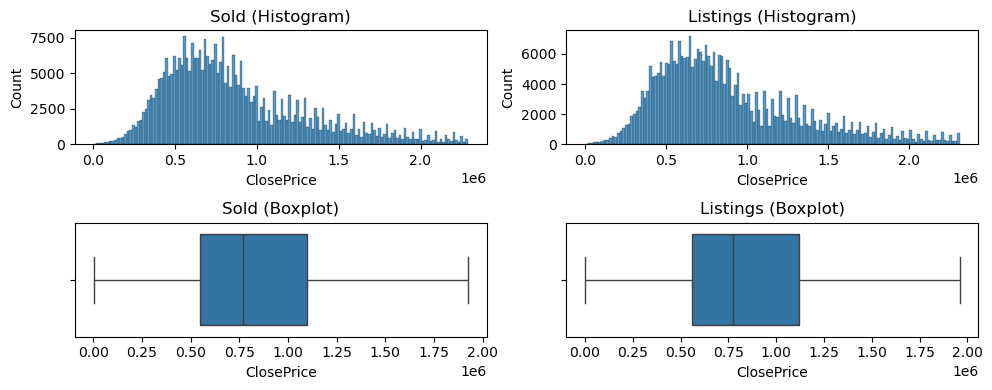

In [38]:
graphs("ClosePrice")

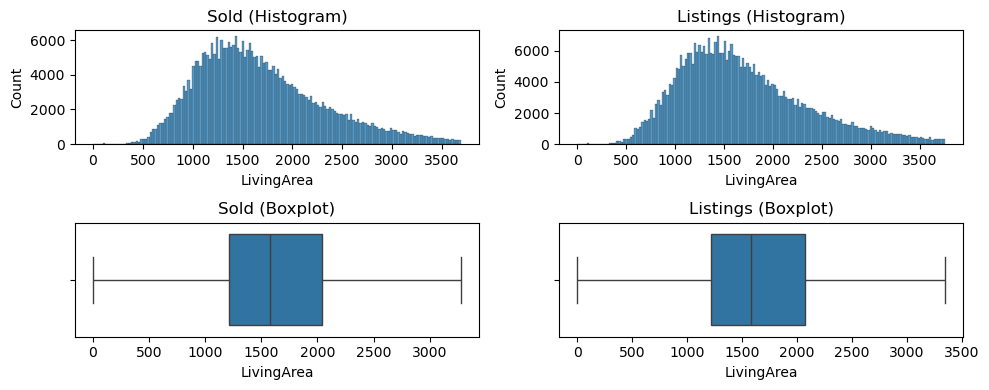

In [39]:
graphs("LivingArea")

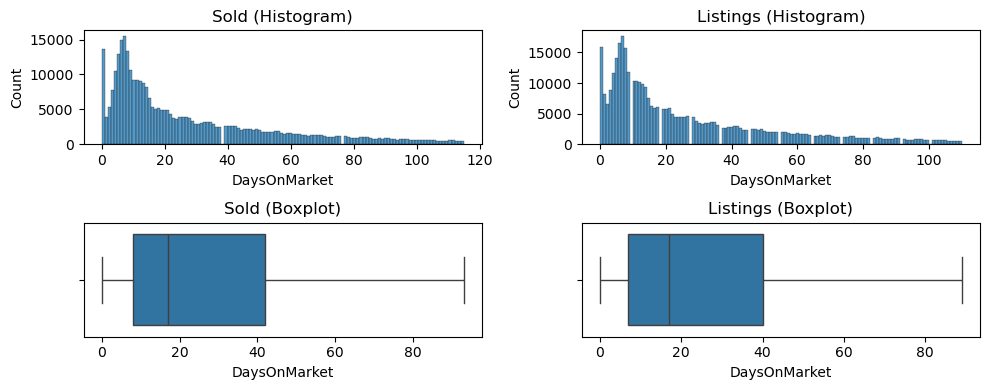

In [40]:
graphs("DaysOnMarket")